# 🖋️ MNIST Handwritten Digit Classification Project

## 📌 Overview
The **MNIST dataset** (Modified National Institute of Standards and Technology) is one of the most popular datasets in machine learning and computer vision.  
It contains **70,000 grayscale images** of handwritten digits (0–9), each sized **28×28 pixels**.  
- **Training set:** 60,000 images  
- **Test set:** 10,000 images  

This project focuses on building and evaluating models that can automatically classify these digits.

---

## 🎯 Project Objectives
- Load and preprocess the MNIST dataset.  
- Build a **neural network** (starting with a simple fully connected model, then moving to CNNs).  
- Train the model using PyTorch.  
- Evaluate performance on the test set.  
- Visualize predictions and misclassifications.  

---

## 🛠️ Tools & Libraries
- **Python 3**  
- **PyTorch** (for deep learning)  
- **Torchvision** (for dataset handling and transforms)  
- **Matplotlib / Seaborn** (for visualization)  
- **NumPy / Pandas** (for data manipulation)  

---

## 📂 Workflow
1. **Import Libraries**  
   Load PyTorch, Torchvision, and visualization tools.  

2. **Dataset Preparation**  
   - Download MNIST using `torchvision.datasets.MNIST`.  
   - Apply transformations (normalization, tensor conversion).  
   - Create DataLoaders for training and testing.  

3. **Model Building**  
   - Start with a simple **Fully Connected Neural Network (FCNN)**.  
   - Extend to a **Convolutional Neural Network (CNN)** for better accuracy.  

4. **Training**  
   - Define loss function (e.g., CrossEntropyLoss).  
   - Use optimizers (SGD, Adam).  
   - Train for multiple epochs, tracking accuracy and loss.  

5. **Evaluation**  
   - Test on unseen data.  
   - Generate confusion matrix and accuracy score.  
   - Visualize sample predictions.  

6. **Results & Insights**  
   - Report accuracy (CNNs typically achieve >99%).  
   - Discuss limitations (MNIST is too simple for modern models).  
   - Suggest extensions (Fashion-MNIST, CIFAR-10).  

---

## 📊 Expected Results
- **Accuracy:** >98% with CNNs.  
- **Visualization:** Correctly classified digits and examples of misclassifications.  
- **Learning Outcome:** Understanding of dataset handling, model building, and evaluation in PyTorch.  

---

## 🚀 Extensions
- Try **Fashion-MNIST** for more complex classification.  
- Experiment with **data augmentation** (rotations, scaling).  
- Deploy the trained model as a simple web app using **Flask** or **FastAPI**.  

---

## ✅ Conclusion
This project is a **foundational exercise** in deep learning.  
It helps build intuition for:
- Neural network architectures  
- Training loops in PyTorch  
- Evaluating and improving models  

The MNIST dataset may be simple, but it remains a **classic benchmark** for learning and experimentation.


using device:  cpu


100%|██████████| 9.91M/9.91M [00:02<00:00, 3.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 193kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.81MB/s]


Epoch 1/5 | loss: 326.2867
Epoch 2/5 | loss: 135.2077
Epoch 3/5 | loss: 90.4108
Epoch 4/5 | loss: 67.0461
Epoch 5/5 | loss: 52.2321
Total Accuracy: 97.48%
Model saved as mnist_model.pth


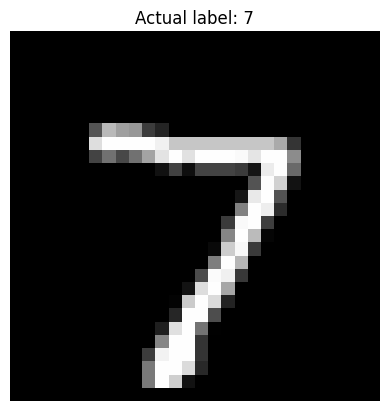

User picked image index: 0
Actual label: 7
Model prediction: 7


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device: ",device)

transform=transforms.ToTensor()

train_data=MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test_data=MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


train_loader=DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)
test_loader=DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)


class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)


model = DigitModel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | loss: {total_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Total Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved as mnist_model.pth")

index = 0
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("User picked image index:", index)
print("Actual label:", true_label)
print("Model prediction:", predicted_label)
